<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Hierarchical%20Clustering" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION
Dataset Shape: (200, 5)

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

MISSING VALUES
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


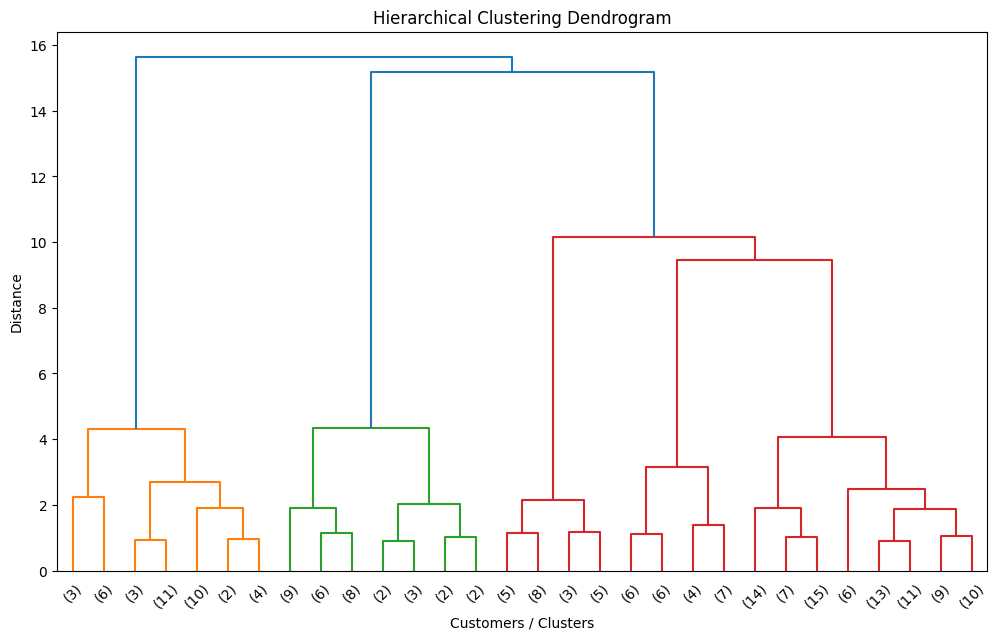


HIERARCHICAL CLUSTERING RESULTS
Number of Clusters: 5
Silhouette Score: 0.5538

Cluster Distribution:
Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64

CLUSTER SUMMARY
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        41.000000           89.406250               15.593750
1        32.692308           86.538462               82.128205
2        42.482353           55.811765               49.129412
3        25.333333           25.095238               80.047619
4        45.217391           26.304348               20.913043


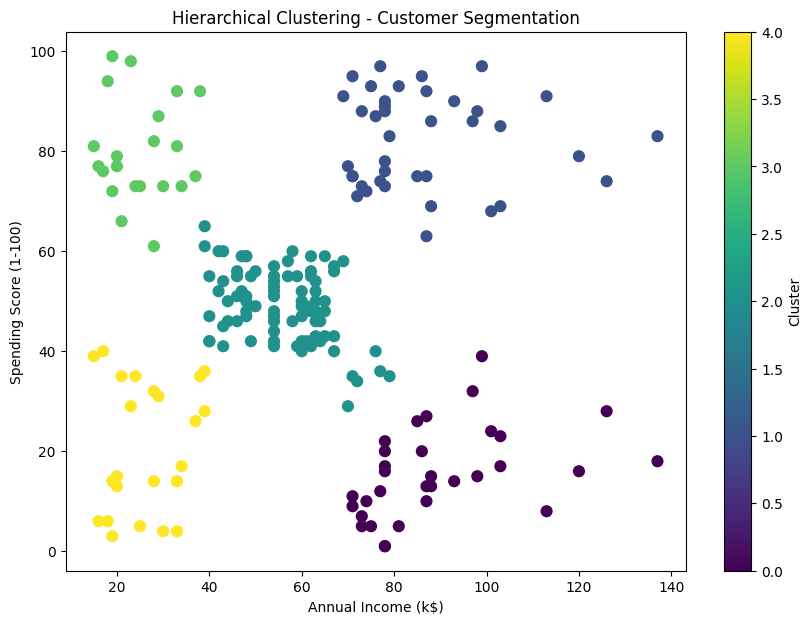


FILE SAVED
hierarchical_customer_segments.csv created successfully.


In [7]:
# ============================================================
# HIERARCHICAL CLUSTERING - CUSTOMER SEGMENTATION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/Mall_Customers.csv")

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())


# ============================================================
# 3. SELECT FEATURES
# ============================================================

# We use Annual Income and Spending Score
# because they are useful for customer segmentation.

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]


# ============================================================
# 4. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 5. DENDROGRAM
# ============================================================

linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Customers / Clusters")

plt.ylabel("Distance")

plt.show()


# ============================================================
# 6. CREATE HIERARCHICAL CLUSTERING MODEL
# ============================================================

# Change n_clusters if your dendrogram suggests another value

n_clusters = 5

model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)


# ============================================================
# 7. PREDICT CLUSTERS
# ============================================================

clusters = model.fit_predict(
    X_scaled
)


# ============================================================
# 8. ADD CLUSTER TO DATASET
# ============================================================

df["Cluster"] = clusters


# ============================================================
# 9. SILHOUETTE SCORE
# ============================================================

silhouette = silhouette_score(
    X_scaled,
    clusters
)

print("\n" + "=" * 70)
print("HIERARCHICAL CLUSTERING RESULTS")
print("=" * 70)

print(
    "Number of Clusters:",
    n_clusters
)

print(
    "Silhouette Score:",
    round(silhouette, 4)
)


# ============================================================
# 10. CLUSTER DISTRIBUTION
# ============================================================

print("\nCluster Distribution:")

print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 11. CLUSTER SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CLUSTER SUMMARY")
print("=" * 70)

summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

print(summary)


# ============================================================
# 12. CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.xlabel(
    "Annual Income (k$)"
)

plt.ylabel(
    "Spending Score (1-100)"
)

plt.title(
    "Hierarchical Clustering - Customer Segmentation"
)

plt.colorbar(
    label="Cluster"
)

plt.show()


# ============================================================
# 13. SAVE RESULT
# ============================================================

df.to_csv(
    "hierarchical_customer_segments.csv",
    index=False
)

print("\n" + "=" * 70)
print("FILE SAVED")
print("=" * 70)

print(
    "hierarchical_customer_segments.csv "
    "created successfully."
)